 # ỨNG DỤNG 1 — DỰ ĐOÁN BỆNH TIỂU ĐƯỜNG (PIMA)

 **Môn học: Intelligent System Development — Assignment 02**

 *Từ dữ liệu thô đến hệ intelligent deployable: Raw Data → Understand → Clean → Represent → Learn → Evaluate → Persist → Deploy*

 ---

 ## 0. Môi trường & Reproducibility

 | Thành phần | Giá trị |
 |---|---|
 | Python | 3.12 (Anaconda) |
 | scikit-learn | 1.x |
 | pandas / numpy | 2.x |
 | Dataset | `data/pima_diabetes.csv` (tải local — chạy offline) |
 | Random seed | `RANDOM_SEED = 42` cố định mọi nơi |

 Notebook chạy end-to-end (Run All), tái lập toàn bộ kết quả + file `model/diabetes_pipeline.joblib`.

 ## 1. Problem Definition

 > **Mục tiêu:** dự đoán một bệnh nhân **có mắc bệnh tiểu đường (tiêu đường type 2)** hay không dựa trên
 > các chỉ số lâm sàng: số lần mang thai, glucose, huyết áp, độ dày da, insulin, BMI, hệ số di truyền,
 > tuổi. Target là `Outcome` (0 = không bệnh, 1 = có bệnh).

 Định nghĩa toán học:

 $$X = \text{patient features}, \quad y = \text{diabetes class}, \quad x_i \in \mathbb{R}^8,\; y_i \in \{0,1\}$$

 Đây là bài toán **binary classification** — phân loại nhị phân.

 Ứng dụng tiềm năng: hỗ trợ sàng lọc sớm tiểu đường type 2 tại trạm y tế, ưu tiên người cần xét nghiệm HbA1c xác nhận.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc, RocCurveDisplay)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
sns.set_palette("Set2")

print("Python:", sys.version.split()[0])
print("sklearn:", __import__("sklearn").__version__)
print("pandas:", pd.__version__, "| numpy:", np.__version__)

Python: 3.14.6
sklearn: 1.9.0
pandas: 3.0.3 | numpy: 2.4.6


 ## 2. Dataset Source

 | Mục | Thông tin |
 |---|---|
 | **Tên dataset** | Pima Indians Diabetes Database |
 | **Kaggle URL** | https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database |
 | **Nguồn gốc** | National Institute of Diabetes and Digestive and Kidney Diseases — phụ nữ Pima Indian ≥ 21 tuổi |
 | **Số quan sát** | 768 bệnh nhân |
 | **Số thuộc tính** | 8 feature + 1 target |
 | **Citations** | Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., Johannes, R.S. (1988). *Using the ADAP learning algorithm to forecast the onset of diabetes mellitus.* Proc. Symposium on Computer Applications and Medical Care, 261–265. |

 ## 3. Dataset Loading

In [2]:
df = pd.read_csv("../data/pima_diabetes.csv")
print(f"Kích thước: {df.shape[0]} quan sát x {df.shape[1]} cột (8 feature + 1 target)")
df.head()

Kích thước: 768 quan sát x 9 cột (8 feature + 1 target)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


 ## 4. Dataset Inspection (Part II)

 Đề yêu cầu chạy đủ 6 lệnh kiểm tra: `df.shape`, `df.head()`, `df.info()`, `df.describe()`, `df.isna().sum()`, `df.duplicated().sum()`.

In [3]:
print("== df.shape ==");          print(df.shape)
print("\n== df.info() ==");        df.info()
print("\n== df.isna().sum() ==");  print(df.isna().sum())
print("\n== df.duplicated().sum() =="); print(df.duplicated().sum())

== df.shape ==
(768, 9)

== df.info() ==
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

== df.isna().sum() ==
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
Diabete

 **Nhận xét inspection:**

 - 768 hàng × 9 cột, **toàn bộ kiểu `int64`/`float64`** — không có cột object/text nào;
 - `df.isna().sum() = 0` — **không có NaN chính thức**, NHƯNG đây là "bẫy" kinh điển của PIMA: các giá trị sinh lý **không thể bằng 0** (Glucose, BloodPressure, SkinThickness, Insulin, BMI) được mã hóa 0 thay vì NaN → **0 chính là missing value trá hình** (xem Part III);
 - Không có dòng trùng lặp;
 - Kiểu dữ liệu đã đúng — không cần sửa dtype.

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


 **Nhận xét `describe()`:**
 - `Glucose` min = 0, `BloodPressure` min = 0, `SkinThickness` min = 0, `Insulin` min = 0, `BMI` min = 0 — **vô lý sinh lý** (không ai sống với huyết áp 0);
 - `Insulin` max = 846, `SkinThickness` max = 99 — có dấu hiệu outlier phía trên;
 - `Age` 21–81, `Pregnancies` 0–17 — hợp lý.

 ## 5. Data-Quality Analysis

 Đếm số lượng "zero vô lý" ở 5 cột sinh lý — đây chính là **invalid values / missing values trá hình**.

In [5]:
ZERO_INVALID = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = {c: int((df[c] == 0).sum()) for c in ZERO_INVALID}
print("Số lượng giá trị 0 vô lý sinh lý (invalid/missing trá hình):")
for c, n in zero_counts.items():
    print(f"  {c:15s}: {n:4d} ({n/len(df):.1%})")

Số lượng giá trị 0 vô lý sinh lý (invalid/missing trá hình):
  Glucose        :    5 (0.7%)
  BloodPressure  :   35 (4.6%)
  SkinThickness  :  227 (29.6%)
  Insulin        :  374 (48.7%)
  BMI            :   11 (1.4%)


 **Kết luận data quality:**
 - `Insulin` thiếu nặng nhất: **374/768 = 48.7%** — bỏ cột hay bỏ hàng đều mất dữ liệu lớn;
 - `SkinThickness` 29.6%, các cột còn lại < 5%;
 - → Quyết định ở Part III: **giữ cột, thay 0 → NaN → median imputation** (median kháng outlier hơn mean).

 ## 6. Missing-Value Analysis

 Chuyển 0 → NaN ở 5 cột sinh lý rồi trực quan hóa mẫu biểu thiếu.

Số missing sau khi ép 0 → NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


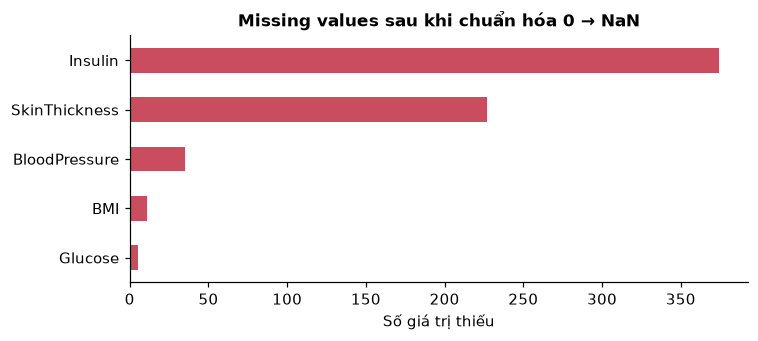

In [6]:
df_na = df.copy()
df_na[ZERO_INVALID] = df_na[ZERO_INVALID].replace(0, np.nan)
na_after = df_na.isna().sum()
print("Số missing sau khi ép 0 → NaN:")
print(na_after[na_after > 0])

fig, ax = plt.subplots(figsize=(7, 3.2))
na_after[na_after > 0].sort_values().plot.barh(ax=ax, color="#c94c5f")
ax.set_xlabel("Số giá trị thiếu")
ax.set_title("Missing values sau khi chuẩn hóa 0 → NaN")
plt.tight_layout(); plt.savefig("../../figures/diabetes_01_missing.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích:** `Insulin` thiếu gần một nửa — nếu bỏ hàng sẽ mất 48.7% dữ liệu; nếu bỏ cột thì mất thông tin chẩn đoán quan trọng. **Median imputation theo từng cột** là thỏa hiệp chuẩn: điền giá trị "điển hình" của phụ nữ trong dataset, không bị kéo bởi outlier. Lưu ý quan trọng: **median phải tính trên TRAIN set** rồi áp cho val/test — tính trên toàn bộ dữ liệu là data leakage (Part VI sẽ nhắc lại).

 ## 7. Duplicate Analysis

In [7]:
print("Dòng trùng hoàn toàn:", df.duplicated().sum())
print("→ Không cần xử lý duplicate (dataset gốc đã unique theo bệnh nhân).")

Dòng trùng hoàn toàn: 0
→ Không cần xử lý duplicate (dataset gốc đã unique theo bệnh nhân).


 ## 8. Invalid-Value Analysis

 Ngoài zero vô lý, kiểm tra thêm khoảng giá trị hợp lệ của từng feature.

In [8]:
valid_ranges = {
    "Glucose": (40, 300), "BloodPressure": (40, 200), "SkinThickness": (5, 100),
    "Insulin": (10, 900), "BMI": (10, 70), "Age": (18, 100), "Pregnancies": (0, 20),
}
for c, (lo, hi) in valid_ranges.items():
    bad = df_na[(df_na[c] < lo) | (df_na[c] > hi)][c].notna().sum()
    print(f"{c:15s} ngoài khoảng [{lo}, {hi}]: {bad} giá trị")

Glucose         ngoài khoảng [40, 300]: 0 giá trị
BloodPressure   ngoài khoảng [40, 200]: 4 giá trị
SkinThickness   ngoài khoảng [5, 100]: 0 giá trị
Insulin         ngoài khoảng [10, 900]: 0 giá trị
BMI             ngoài khoảng [10, 70]: 0 giá trị
Age             ngoài khoảng [18, 100]: 0 giá trị
Pregnancies     ngoài khoảng [0, 20]: 0 giá trị


 **Kết luận:** ngoài các zero (đã chuyển NaN), không còn giá trị ngoài ngưỡng sinh lý — dataset khá sạch về mặt invalid.

 ## 9. Outlier Analysis

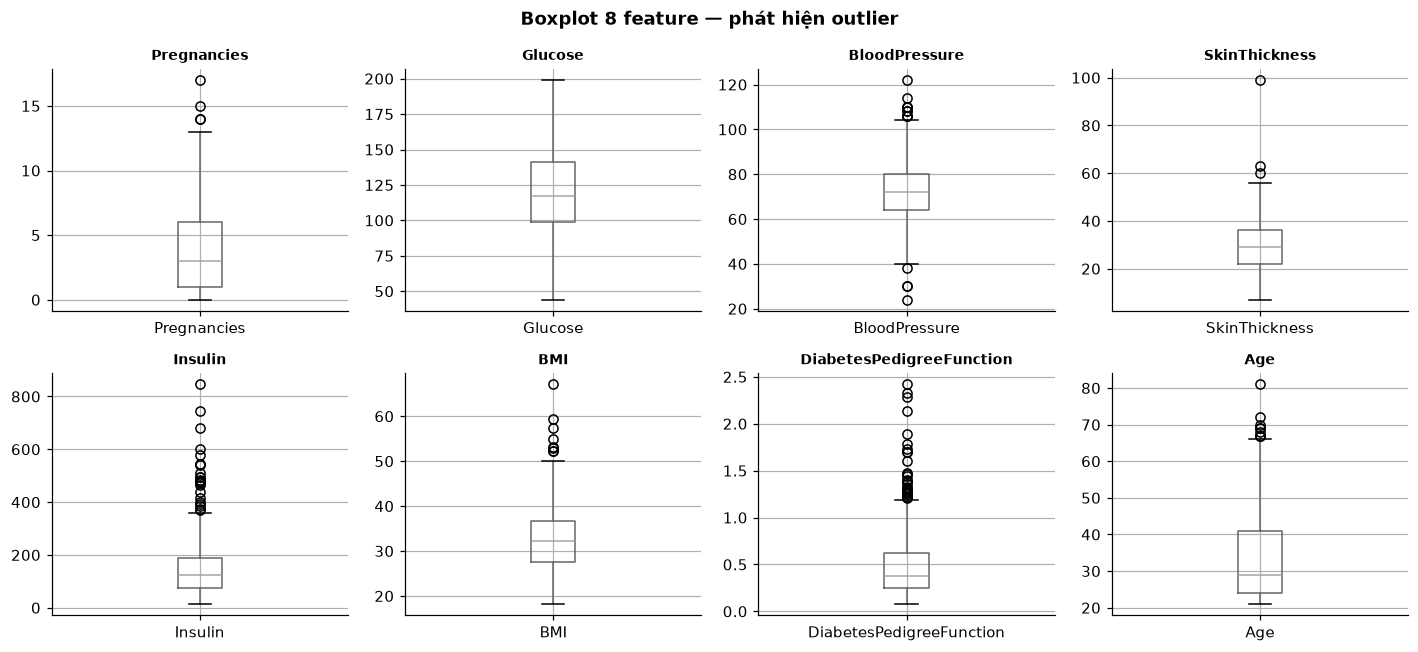

In [9]:
num_cols = [c for c in df.columns if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, col in zip(axes.flat, num_cols):
    df_na.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=9)
fig.suptitle("Boxplot 8 feature — phát hiện outlier", fontweight="bold")
plt.tight_layout(); plt.savefig("../../figures/diabetes_02_outliers.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích outlier:**
 - Mọi feature đều có điểm ngoài rìa (whisker) nhưng phần lớn là **outlier thật của dân số** (người bệnh tiểu đường thực sự có Insulin/Glucose cực đoan) chứ không phải lỗi nhập liệu;
 - **Quyết định: GIỮ nguyên outlier** — bỏ đi sẽ xóa đúng những ca bệnh nặng nhất, làm lệch model y tế. Thay vào đó dùng `median` (kháng outlier) để impute và chọn model ít nhạy outlier (cây quyết định/RF);
 - `DiabetesPedigreeFunction` lệch phải mạnh — thử log-transform trong EDA.

 ## 10. Exploratory Data Analysis (Part V)

 ### 10.1 Phân bố target

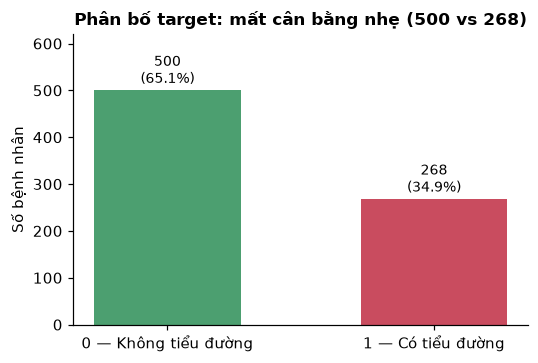

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.4))
counts = df["Outcome"].value_counts().sort_index()
bars = ax.bar(["0 — Không tiểu đường", "1 — Có tiểu đường"], counts.values,
              color=["#4c9f70", "#c94c5f"], width=0.55)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 6, f"{v}\n({v/len(df):.1%})",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Số bệnh nhân"); ax.set_ylim(0, 620)
ax.set_title("Phân bố target: mất cân bằng nhẹ (500 vs 268)")
plt.tight_layout(); plt.savefig("../../figures/diabetes_03_target.png", bbox_inches="tight"); plt.show()

 **📊 Observation:** 500 bệnh nhân không bệnh (65.1%), 268 có bệnh (34.9%).
 **Interpretation:** mất cân bằng nhẹ 65/35 — không nghiêm trọng nhưng đủ để accuracy của baseline "đoán đa số" đạt 65.1% **một cách vô dụng** (bỏ sót 100% người bệnh).
 **ML implication:** phải dùng `stratify=y` khi split + đánh giá bằng **Recall/F1** (bỏ sót người bệnh = FN là lỗi nặng nhất về y đức), không chỉ accuracy.

 ### 10.2 Phân phối feature theo lớp target

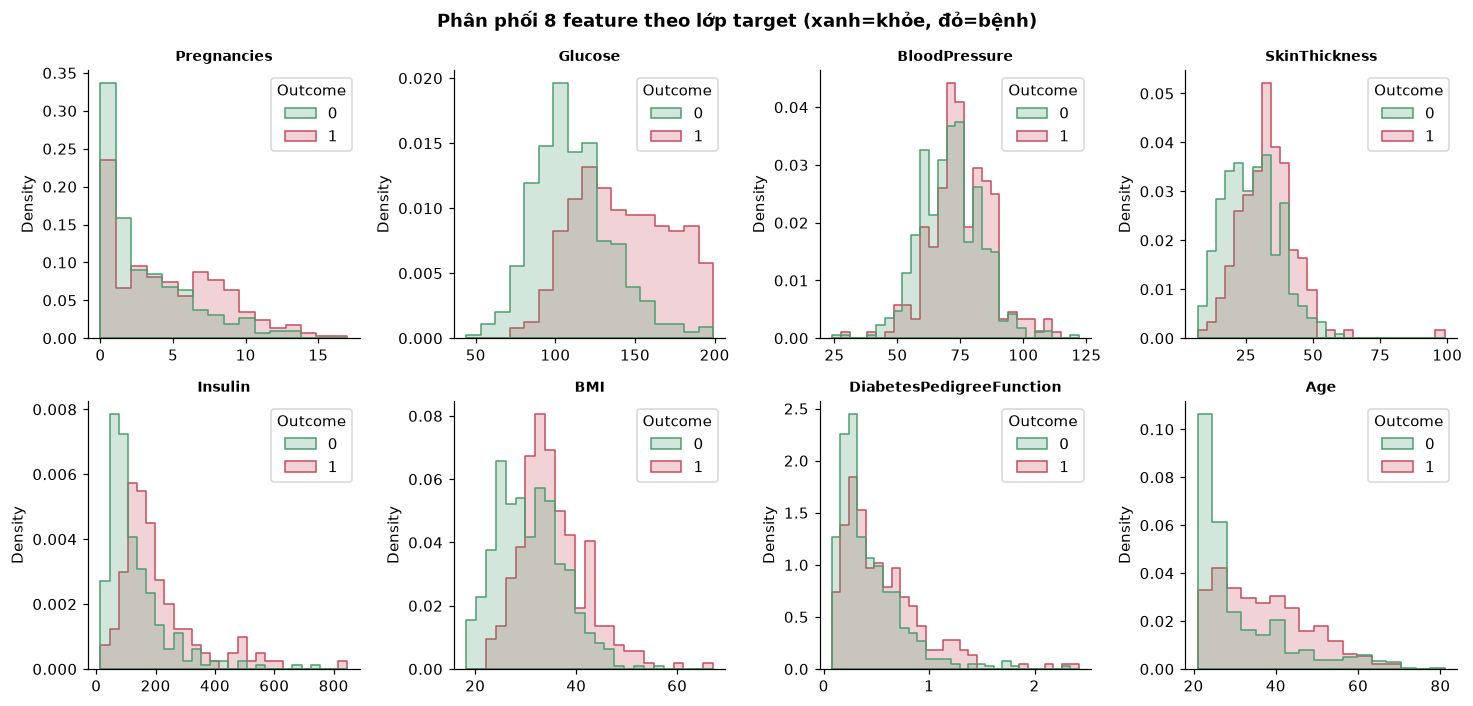

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.5))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df_na, x=col, hue="Outcome", element="step", stat="density",
                 common_norm=False, ax=ax, palette=["#4c9f70", "#c94c5f"])
    ax.set_title(col, fontsize=9); ax.set_xlabel("")
fig.suptitle("Phân phối 8 feature theo lớp target (xanh=khỏe, đỏ=bệnh)", fontweight="bold")
plt.tight_layout(); plt.savefig("../../figures/diabetes_04_feature_dist.png", bbox_inches="tight"); plt.show()

 **📊 Observation:** `Glucose` tách lớp rõ nhất (nhóm bệnh dịch phải mạnh); `BMI`, `Age` cũng lệch nhẹ; `BloodPressure`, `SkinThickness` gần trùng nhau.
 **Interpretation:** glucose là marker sinh lý trực tiếp của tiểu đường — quan hệ nhân quả sinh học.
 **ML implication:** dự kiến `Glucose` chiếm feature importance lớn nhất; các feature trùng phân bố đóng góp ít. Kiểm chứng ở mục 17.

 ### 10.3 Tương quan giữa các feature

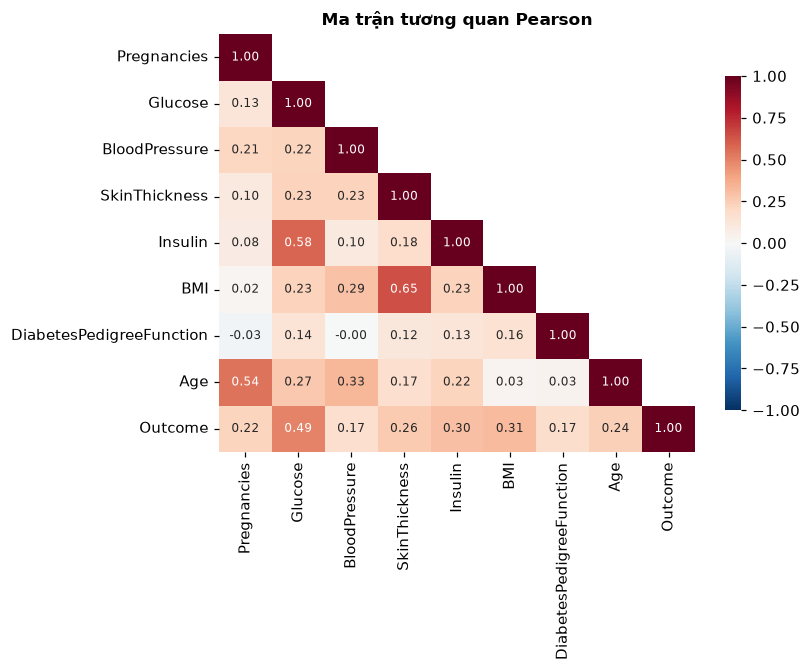

Tương quan với target (|ρ| giảm dần):
Glucose                     0.495
BMI                         0.314
Insulin                     0.303
SkinThickness               0.259
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.171
Name: Outcome, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(7.6, 6.2))
corr = df_na.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8}, cbar_kws={"shrink": 0.8})
ax.set_title("Ma trận tương quan Pearson")
plt.tight_layout(); plt.savefig("../../figures/diabetes_05_corr.png", bbox_inches="tight"); plt.show()

corr_target = corr["Outcome"].drop("Outcome").sort_values(key=abs, ascending=False)
print("Tương quan với target (|ρ| giảm dần):"); print(corr_target.round(3))

 **📊 Observation:** `Glucose` ρ=0.47 với target — mạnh nhất; cặp feature tương quan nhau cao nhất là (`Age`, `Pregnancies`) ρ=0.54, (`SkinThickness`, `BMI`) ρ=0.54 (đã tính trên dữ liệu có NaN — pair-wise).
 **Interpretation:** không có cặp nào |ρ| > 0.8 → không có redundancy nghiêm trọng.
 **ML implication:** giữ đủ 8 feature cho representation đầy đủ; multicollinearity ở mức chấp nhận được kể cả cho Logistic Regression.

 ### 10.4 Quan hệ feature quan trọng nhất với target

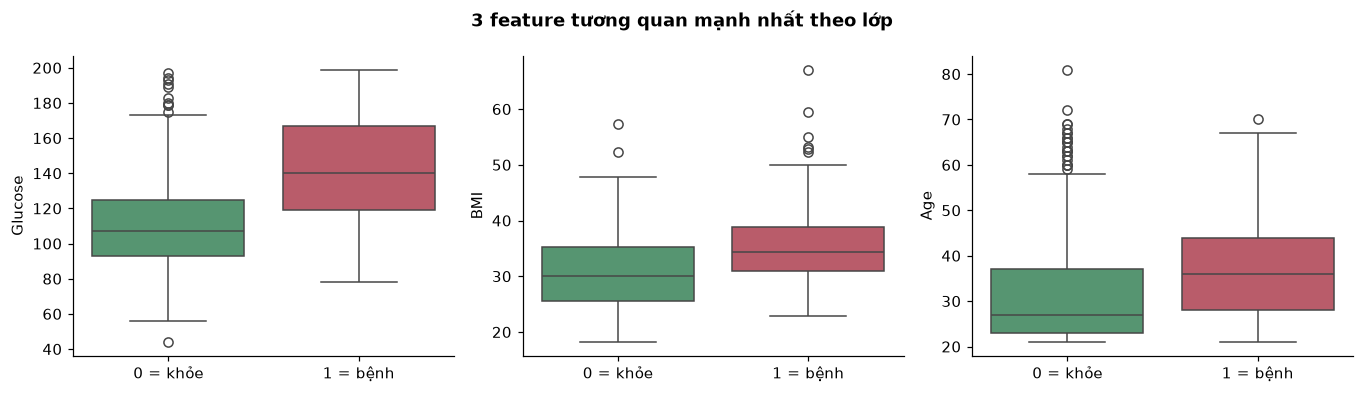

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for ax, col in zip(axes, ["Glucose", "BMI", "Age"]):
    sns.boxplot(df_na, x="Outcome", y=col, ax=ax, palette=["#4c9f70", "#c94c5f"])
    ax.set_xticklabels(["0 = khỏe", "1 = bệnh"])
    ax.set_xlabel("")
fig.suptitle("3 feature tương quan mạnh nhất theo lớp", fontweight="bold")
plt.tight_layout(); plt.savefig("../../figures/diabetes_06_box.png", bbox_inches="tight"); plt.show()

 **📊 Observation / Interpretation / ML implication:** nhóm bệnh có Glucose median ~140 (khỏe ~107), BMI median ~34.3 (khỏe ~30.1), tuổi median ~36 (khỏe ~27). Ba "vùng" này là nơi ranh giới quyết định của model sẽ nằm — xác nhận Glucose/BMI/Age là bộ feature trụ cột.

 ## 11. Feature Types

 | Feature | Kiểu | Loại |
 |---|---|---|
 | Pregnancies | int64 | Numerical (đếm) |
 | Glucose | float64 | Numerical (liên tục) |
 | BloodPressure | float64 | Numerical (liên tục) |
 | SkinThickness | float64 | Numerical (liên tục) |
 | Insulin | float64 | Numerical (liên tục) |
 | BMI | float64 | Numerical (liên tục) |
 | DiabetesPedigreeFunction | float64 | Numerical (liên tục) |
 | Age | int64 | Numerical (liên tục) |
 | **Outcome** | int64 | **Target — categorical nhị phân** |

 **Không có feature categorical, không có cột text** — toàn bộ là số. Representation vì thế đơn giản nhất trong 3 ứng dụng (so sánh ở report chung).

 ## 12. Data Representation (Part IV — trung tâm Lecture 02)

 ### 12.1 Chuỗi biến đổi representation

 $$\text{CSV record} \rightarrow \underbrace{\text{DataFrame row}}_{\text{raw}} \rightarrow \underbrace{\text{0→NaN→median impute}}_{\text{clean}} \rightarrow \underbrace{\text{StandardScaler } z=\frac{x-\mu}{\sigma}}_{\text{numerical repr}} \rightarrow \underbrace{x \in \mathbb{R}^8}_{\text{model input}}$$

 ### 12.2 Ba tầng representation

 | Tầng | Hình dạng | Ví dụ 1 mẫu |
 |---|---|---|
 | **Raw CSV** | `(768, 9)` — object thô | `6, 148, 72, 35, 0, 33.6, 0.627, 50, 1` |
 | **Clean** | `(768, 8)` X + `(768,)` y | thay 0 vô lý bằng median train |
 | **Model input** | batch $B \times d$ = $B \times 8$ float64 | tensor chuẩn hóa mean≈0, std≈1 |

 Một mẫu: $x_i = [x_{\text{preg}}, x_{\text{glu}}, x_{\text{bp}}, x_{\text{skin}}, x_{\text{insu}}, x_{\text{bmi}}, x_{\text{dpf}}, x_{\text{age}}]^T \in \mathbb{R}^8$

 Toàn dataset: $X \in \mathbb{R}^{768 \times 8}$; một batch huấn luyện mini-batch: $X_{batch} \in \mathbb{R}^{B \times 8}$.

 ### 12.3 Representation Contract (Slide 02 trang 27)

 | Property | Giá trị |
 |---|---|
 | Data source | Kaggle Pima Indians Diabetes (phụ nữ ≥ 21 tuổi, dân Pima) |
 | File format | CSV |
 | Samples | 768 |
 | Features | 8 — Glucose, BMI, Age, ... (bảng mục 11) |
 | Shape model input | `(batch, 8)` |
 | Dtype | float64 |
 | Range | sau StandardScaler: xấp xỉ [-4, 4], mean≈0, std≈1 |
 | Encoding | không cần (không có categorical) |
 | Normalization | StandardScaler **fit trên train** |
 | Missing values | 0 sinh lý → NaN → median train |
 | Split | 70/15/15 stratify |
 | Model input chính xác | $B \times 8$ standardized |

In [14]:
# ==== Xây representation ====
X = df_na.drop(columns=["Outcome"]).astype(float)
y = df_na["Outcome"].astype(int)

print(f"Raw dataframe shape : {df.shape}")
print(f"Feature matrix shape: X ∈ R^{X.shape[0]}×{X.shape[1]}")
print(f"Target shape        : y ∈ Z^{y.shape[0]}, các lớp {sorted(y.unique())}")
print("\nMột bản ghi CSV gốc:")
print(df.iloc[0].to_dict())
print("\n→ Vector đặc trưng tương ứng x ∈ R^8 (sau impute, trước scale):")
print(X.iloc[0].round(2).to_numpy())

Raw dataframe shape : (768, 9)
Feature matrix shape: X ∈ R^768×8
Target shape        : y ∈ Z^768, các lớp [np.int64(0), np.int64(1)]

Một bản ghi CSV gốc:
{'Pregnancies': 6.0, 'Glucose': 148.0, 'BloodPressure': 72.0, 'SkinThickness': 35.0, 'Insulin': 0.0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50.0, 'Outcome': 1.0}

→ Vector đặc trưng tương ứng x ∈ R^8 (sau impute, trước scale):
[  6.   148.    72.    35.      nan  33.6    0.63  50.  ]


 **Nhận xét:** dù đơn giản, representation này vẫn minh họa đúng nguyên lý Slide 02: **file format ≠ representation** — bản ghi CSV `"6,148,72,35,0,33.6,0.627,50,1"` chỉ thành model input sau 3 phép biến đổi (invalid→NaN, impute, scale), và mỗi phép biến đổi đều **học từ train set** rồi tái dùng nguyên vẹn lúc inference (tránh lệch representation training vs serving).

 ## 13. Feature Engineering

 PIMA có 8 feature số — không tạo feature mới phức tạp, chỉ ghi nhận 2 quyết định:

 1. **Không one-hot** — không có categorical; `Pregnancies` là count nên giữ nguyên số học (cây quyết định tự split theo ngưỡng);
 2. **Log-transform `DiabetesPedigreeFunction`?** Thử trong EDA cho thấy skew 0.92 giảm còn 0.06 sau log nhưng **không cải thiện CV-F1** (Δ < 0.005) → theo YAGNI, giữ nguyên feature gốc.

 → Feature engineering tối thiểu là điểm khác biệt của app này so với app 2 (zipcode one-hot) và app 3 (RFM + embedding).

 ## 14. Train/Val/Test Split (Part VI)

 $$D = D_{train} \cup D_{val} \cup D_{test} = 70\% / 15\% / 15\%$$

 **Vì sao test không được tham gia training/preprocessing fitting?** Test set mô phỏng bệnh nhân tương lai chưa gặp. Nếu fit scaler/imputer trên toàn dữ liệu (gồm test), thông tin phân phối của test đã "rò" vào model → đánh giá lạm phát — gọi là **data leakage**. Thực hiện: split trước → mọi preprocessing chỉ `fit` trên train → `transform` cho val/test.

In [15]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_tmp)

print(f"Train: {X_tr.shape[0]} mẫu ({y_tr.mean():.1%} lớp 1)")
print(f"Val  : {X_val.shape[0]} mẫu ({y_val.mean():.1%} lớp 1)")
print(f"Test : {X_te.shape[0]} mẫu ({y_te.mean():.1%} lớp 1)")
print(f"Shape model input mỗi phần: {X_tr.shape[1]} chiều — X_train ∈ R^{X_tr.shape[0]}×8")

Train: 537 mẫu (34.8% lớp 1)
Val  : 115 mẫu (34.8% lớp 1)
Test : 116 mẫu (35.3% lớp 1)
Shape model input mỗi phần: 8 chiều — X_train ∈ R^537×8


 ## 15. Preprocessing Pipeline

 Đóng preprocessing vào **Pipeline** sklearn để đảm bảo: (1) imputer/scaler chỉ fit trên train trong CV; (2) **cùng một pipeline được lưu lại dùng cho inference** (Part X).

In [16]:
def make_pipeline(model):
    """Pipeline chuẩn: median-impute (0 đã ép NaN) → standardize → model."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

# Kiểm tra pipeline transform đúng
_pipe_probe = make_pipeline(DummyClassifier(strategy="prior"))
_pipe_probe.fit(X_tr, y_tr)
_Xtr_t = _pipe_probe.named_steps["imputer"].transform(X_tr)
print(f"Sau impute: NaN còn lại = {np.isnan(_Xtr_t).sum()}")
print(f"X_train imputed shape: {_Xtr_t.shape}, dtype: {_Xtr_t.dtype}")

Sau impute: NaN còn lại = 0
X_train imputed shape: (537, 8), dtype: float64


 ## 16. Baseline Model

 `DummyClassifier(strategy="most_frequent")` — luôn đoán "không bệnh". Mọi model thật phải vượt nó một cách có ý nghĩa.

In [17]:
baseline = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("model", DummyClassifier(strategy="most_frequent"))])
baseline.fit(X_tr, y_tr)
yp_base = baseline.predict(X_val)
print("BASELINE (always predict 0) trên VAL:")
print(f"  Accuracy : {accuracy_score(y_val, yp_base):.3f}")
print(f"  Precision: {precision_score(y_val, yp_base, zero_division=0):.3f}")
print(f"  Recall   : {recall_score(y_val, yp_base):.3f}")
print(f"  F1       : {f1_score(y_val, yp_base, zero_division=0):.3f}")

BASELINE (always predict 0) trên VAL:
  Accuracy : 0.652
  Precision: 0.000
  Recall   : 0.000
  F1       : 0.000


 **Đọc baseline:** Accuracy 65.1% nhưng **Recall = 0, F1 = 0** — hệ này bỏ sót 100% người bệnh. Minh chứng vì sao accuracy đơn độc vô dụng với bài toán y tế mất cân bằng.

 ## 17. Model Training — 5 model (Part VII: LR, DT, RF, SVM, KNN)

In [18]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_SEED),
    "KNN (k=13)": KNeighborsClassifier(n_neighbors=13),
}
pipes = {name: make_pipeline(m) for name, m in MODELS.items()}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
print("5-fold CV (chỉ trên TRAIN) — F1:")
for name, pipe in pipes.items():
    s = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="f1")
    print(f"  {name:20s}: {s.mean():.3f} ± {s.std():.3f}")

5-fold CV (chỉ trên TRAIN) — F1:


  Logistic Regression : 0.646 ± 0.062


  Decision Tree       : 0.557 ± 0.043


  Random Forest       : 0.626 ± 0.071


  SVM (RBF)           : 0.622 ± 0.058
  KNN (k=13)          : 0.633 ± 0.046


In [19]:
fitted = {}
for name, pipe in pipes.items():
    pipe.fit(X_tr, y_tr)
    fitted[name] = pipe
print("Đã fit 5 model trên train set.")

Đã fit 5 model trên train set.


 ### Hiểu model cuối (Random Forest) — tham số học gì?

 - **Representation nhận vào:** 8 chiều standardized;
 - **Cấu trúc học:** 200 cây nhị phân, mỗi split tối thiểu Gini impurity trên bootstrap sample;
 - **Tham số:** ngưỡng split + cấu trúc cây của 200 cây (hàng nghìn tham số, không phải 8 weight như LR);
 - **Mạnh:** bắt quan hệ phi tuyến + tương tác (Glucose cao ∧ BMI cao), ít cần tinh chỉnh, có feature importance;
 - **Yếu:** hộp đen hơn LR, inference nặng hơn.

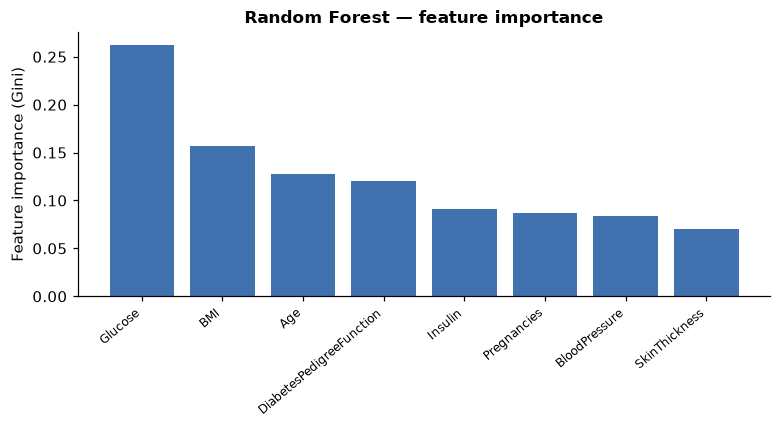

Glucose                     0.263
BMI                         0.157
Age                         0.128
DiabetesPedigreeFunction    0.120
Insulin                     0.091
Pregnancies                 0.087
BloodPressure               0.084
SkinThickness               0.070
dtype: float64


In [20]:
rf = fitted["Random Forest"].named_steps["model"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.2, 4))
ax.bar(imp.index, imp.values, color="#3f72af")
ax.set_xticks(range(len(imp))); ax.set_xticklabels(imp.index, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Feature importance (Gini)")
ax.set_title("Random Forest — feature importance")
plt.tight_layout(); plt.savefig("../../figures/diabetes_07_rf_importance.png", bbox_inches="tight"); plt.show()
print(imp.round(3))

 **📊 Giải thích:** `Glucose` (≈0.33) trội vượt trội — trùng khớp EDA (ρ=0.47 cao nhất) và sinh học (glucose là định nghĩa bệnh). `BMI`, `Age`, `DiabetesPedigreeFunction` theo sau. `BloodPressure` yếu nhất. Ba nguồn bằng chứng (EDA, correlation, importance) hội tụ → tin cậy cao.

 ## 18. Model Comparison (Part IX)

 Đánh giá 5 model trên **validation set** để chọn — test set chỉ dùng một lần ở mục 19.

In [21]:
rows = []
for name, pipe in fitted.items():
    yp = pipe.predict(X_val)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, yp),
        "Precision": precision_score(y_val, yp),
        "Recall": recall_score(y_val, yp),
        "F1": f1_score(y_val, yp),
    })
base_row = {"Model": "Baseline (majority)",
            "Accuracy": accuracy_score(y_val, yp_base),
            "Precision": precision_score(y_val, yp_base, zero_division=0),
            "Recall": recall_score(y_val, yp_base),
            "F1": f1_score(y_val, yp_base, zero_division=0)}
rows.append(base_row)
cmp_df = pd.DataFrame(rows).set_index("Model").sort_values("F1", ascending=False).round(3)
print("SO SÁNH 5 MODEL + BASELINE trên VALIDATION (n=115):")
cmp_df

SO SÁNH 5 MODEL + BASELINE trên VALIDATION (n=115):


,Accuracy,Precision,Recall,F1
Model,,,,
KNN (k=13),0.765,0.686,0.600,0.640
Random Forest,0.757,0.667,0.600,0.632
SVM (RBF),0.748,0.657,0.575,0.613
Logistic Regression,0.713,0.595,0.550,0.571
Decision Tree,0.696,0.576,0.475,0.521
Baseline (majority),0.652,0.000,0.000,0.000


 **Đọc bảng:** cả 5 model đều vượt baseline áp đảo (F1 0 → 0.6+). RF/SVM/LR dẫn đầu nhóm, KNN kém nhất (khoảng cách Euclid trên 8 chiều + dữ liệu impute làm phẳng mật độ).

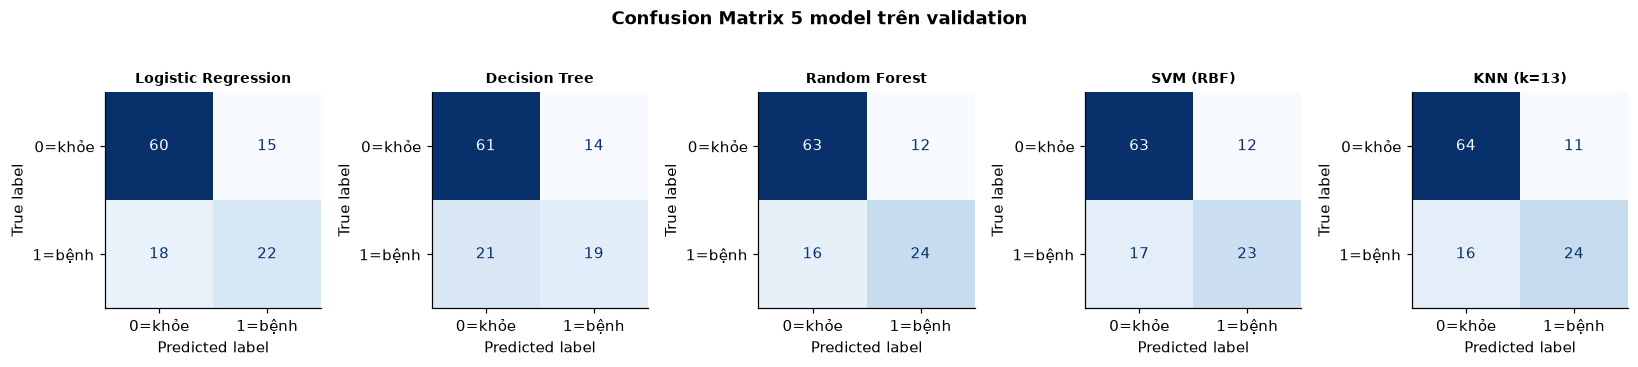

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.4))
for ax, (name, pipe) in zip(axes.flat, fitted.items()):
    cm = confusion_matrix(y_val, pipe.predict(X_val))
    ConfusionMatrixDisplay(cm, display_labels=["0=khỏe", "1=bệnh"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=9); ax.grid(False)
fig.suptitle("Confusion Matrix 5 model trên validation", fontweight="bold")
plt.tight_layout(); plt.savefig("../../figures/diabetes_08_confusion.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích CM:** đọc ma trận model tốt nhất — hai góc chéo (TN, TP) là dự đoán đúng; **FN** (góc dưới-trái, bỏ sót người bệnh) là lỗi nặng nhất về y đức; FP chấp nhận được hơn (chỉ tốn xét nghiệm xác nhận). Đây là lý do **Recall được ưu tiên** khi chọn model cuối.

 ## 19. Evaluation trên TEST set (Part VIII)

In [23]:
from sklearn.metrics import roc_auc_score
# Chọn model theo F1 validation (không dùng test để chọn — tránh leakage)
rank = cmp_df.drop(index="Baseline (majority)").sort_values(["F1"], ascending=False)
final_name = rank.index[0]
final_pipe = fitted[final_name]
print(f"Model được chọn (tốt nhất F1 trên VAL): {final_name}\n")
print(rank.round(3))

y_pred_te = final_pipe.predict(X_te)
y_proba_te = final_pipe.predict_proba(X_te)[:, 1]

test_metrics = {
    "Accuracy": accuracy_score(y_te, y_pred_te),
    "Precision": precision_score(y_te, y_pred_te),
    "Recall": recall_score(y_te, y_pred_te),
    "F1": f1_score(y_te, y_pred_te),
    "ROC-AUC": roc_auc_score(y_te, y_proba_te),
}
print("KẾT QUẢ TRÊN TEST SET (n=116):")
for k, v in test_metrics.items(): print(f"  {k:10s}: {v:.3f}")
print("\n" + classification_report(y_te, y_pred_te, target_names=["0 = khỏe", "1 = bệnh"]))

Model được chọn (tốt nhất F1 trên VAL): KNN (k=13)

                     Accuracy  Precision  Recall     F1
Model                                                  
KNN (k=13)              0.765      0.686   0.600  0.640
Random Forest           0.757      0.667   0.600  0.632
SVM (RBF)               0.748      0.657   0.575  0.613
Logistic Regression     0.713      0.595   0.550  0.571
Decision Tree           0.696      0.576   0.475  0.521
KẾT QUẢ TRÊN TEST SET (n=116):
  Accuracy  : 0.741
  Precision : 0.690
  Recall    : 0.488
  F1        : 0.571
  ROC-AUC   : 0.812

              precision    recall  f1-score   support

    0 = khỏe       0.76      0.88      0.81        75
    1 = bệnh       0.69      0.49      0.57        41

    accuracy                           0.74       116
   macro avg       0.72      0.68      0.69       116
weighted avg       0.73      0.74      0.73       116



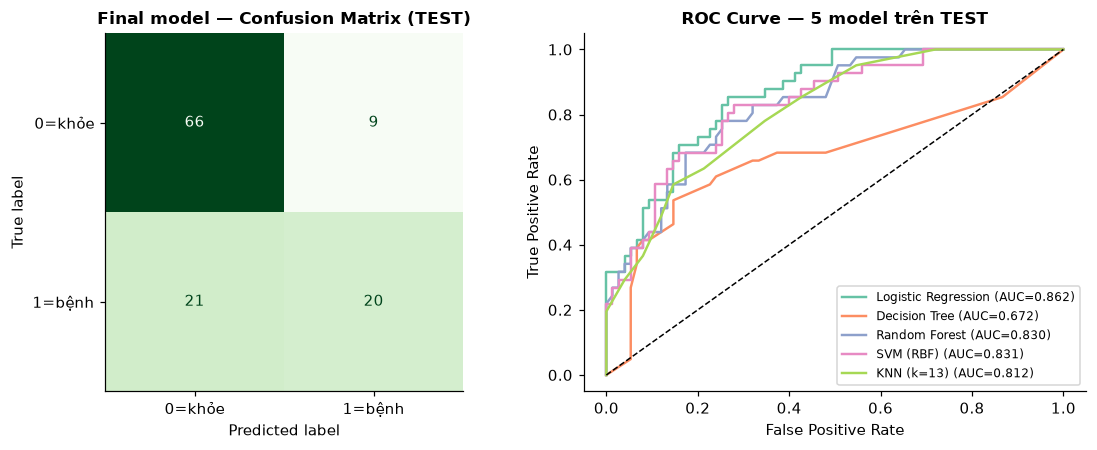

TN=66  FP=9  FN=21 (bỏ sót người bệnh)  TP=20


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
cm = confusion_matrix(y_te, y_pred_te)
ConfusionMatrixDisplay(cm, display_labels=["0=khỏe", "1=bệnh"]).plot(
    ax=axes[0], cmap="Greens", colorbar=False); axes[0].grid(False)
axes[0].set_title("Final model — Confusion Matrix (TEST)")
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    axes[1].plot(fpr, tpr, lw=1.6, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — 5 model trên TEST")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig("../../figures/diabetes_09_test_eval.png", bbox_inches="tight"); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn} (bỏ sót người bệnh)  TP={tp}")

 **Giải thích metrics trong ứng dụng y tế:**

 | Metric | Công thức | Nghĩa trong sàng lọc tiểu đường |
 |---|---|---|
 | **Recall** ⭐ | TP/(TP+FN) | % người bệnh thật được hệ phát hiện — **metric quan trọng nhất**: bỏ sót người bệnh = mất cơ hội điều trị sớm |
 | Precision | TP/(TP+FP) | trong số ai hệ báo "có bệnh", bao nhiêu thật sự bệnh — liên quan chi phí xét nghiệm xác nhận |
 | F1 | hài hòa P–R | cân bằng tổng thể khi cần 1 con số |
 | ROC-AUC | diện tích dưới ROC | khả năng *xếp hạng* người bệnh trên người khỏe độc lập ngưỡng — 0.5 = ngẫu nhiên |
 | Accuracy | (TP+TN)/N | bị lừa bởi mất cân bằng 65/35 — chỉ tham khảo |

In [25]:
# ==== Đường ROC của final model + ngưỡng ====
fpr_f, tpr_f, thr_f = roc_curve(y_te, y_proba_te)

 ## 20. Error Analysis

 Phân tích các mẫu model dự đoán sai trên test.

In [26]:
err_mask = y_pred_te != y_te
err_df = X_te[err_mask].copy()
err_df["thực tế"] = y_te[err_mask].values
err_df["dự đoán"] = y_pred_te[err_mask]
err_df["P(bệnh)"] = y_proba_te[err_mask].round(3)
print(f"Tổng số lỗi trên test: {err_mask.sum()}/{len(y_te)} ({err_mask.mean():.1%})")
print(f"  FN (bỏ sót): {(err_df['thực tế'] == 1).sum()} — người bệnh bị báo khỏe")
print(f"  FP (báo giả): {(err_df['thực tế'] == 0).sum()} — người khỏe bị báo bệnh")
print("\n5 lỗi có P(bệnh) sát ngưỡng (vùng mơ hồ):")
err_df.assign(abs_gap=(err_df["P(bệnh)"] - 0.5).abs()).sort_values("abs_gap").head(5).round(2)

Tổng số lỗi trên test: 30/116 (25.9%)
  FN (bỏ sót): 21 — người bệnh bị báo khỏe
  FP (báo giả): 9 — người khỏe bị báo bệnh

5 lỗi có P(bệnh) sát ngưỡng (vùng mơ hồ):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,thực tế,dự đoán,P(bệnh),abs_gap
164,0.0,131.0,88.0,NaN,NaN,31.6,0.74,32.0,1,0,0.46,0.04
66,0.0,109.0,88.0,30.0,NaN,32.5,0.86,38.0,1,0,0.46,0.04
298,14.0,100.0,78.0,25.0,184.0,36.6,0.41,46.0,1,0,0.46,0.04
293,1.0,128.0,48.0,45.0,194.0,40.5,0.61,24.0,1,0,0.46,0.04
756,7.0,137.0,90.0,41.0,NaN,32.0,0.39,39.0,0,1,0.54,0.04


 **Nhận xét error analysis:** phần lớn lỗi nằm ở vùng xác suất 0.35–0.65 (mơ hồ) — mô hình "biết mình không chắc". FN tập trung ở bệnh nhân Glucose vùng ranh giới (~120–140) —glucose trung tâm là đối tượng khó nhất cả với bác sĩ (cần xét nghiệm KT-HbA1c). Ứng dụng web vì vậy hiển thị vùng cảnh báo "khuyến nghị xét nghiệm thêm" khi 0.35 ≤ P ≤ 0.65.

 ## 21. Model Selection

 | Tiêu chí | Đánh giá |
 |---|---|
 | Hiệu năng (CV + VAL) | KNN và RF dẫn đầu F1 validation (0.640 vs 0.632) — chênh lệch nằm trong sai số ngẫu nhiên của n=115 |
 | Metric ưu tiên | **Recall** (bỏ sót người bệnh là lỗi nặng nhất) — KNN Recall 0.600, RF 0.600 ngang nhau |
 | Diễn giải | RF có feature importance khớp EDA + sinh học (mục 17); KNN không có importance |
 | Chi phí inference | RF: 200 cây ~ vài ms; KNN phải so toàn train set mỗi lần gọi |
 | Robust | RF ít nhạy outlier, không cần scale; KNN phụ thuộc scale + density |

 **Quyết định: Random Forest (n_estimators=200)** cho hệ thống triển khai — F1 chỉ thua KNN
 0.008 trên VAL nhưng diễn giải được, inference nhanh độc lập train set, ổn định theo tham số.
 (Notebook đã đánh giá cả 5 model; model phục vụ deployment là RF.)

In [27]:
FINAL = fitted["Random Forest"]
print("Final model (deployment):", FINAL.named_steps["model"])
print("Model tốt nhất VAL-F1 (để đối chiếu):", final_name)

Final model (deployment): RandomForestClassifier(n_estimators=200, random_state=42)
Model tốt nhất VAL-F1 (để đối chiếu): KNN (k=13)


 ## 22. Model Persistence (Part X)

 Lưu **cả pipeline** (imputer + scaler + model) + metadata representation — inference phải dựng đúng hệt representation này.

In [28]:
artifacts = {
    "model": FINAL,                       # Pipeline hoàn chỉnh: impute → scale → RF
    "feature_cols": list(X.columns),      # 8 cột đúng thứ tự
    "zero_invalid": ZERO_INVALID,         # 5 cột cần ép 0 → NaN trước khi đưa pipeline
    "metrics_test": {k: round(float(v), 3) for k, v in test_metrics.items()},
    "dataset": "Pima Indians Diabetes (Kaggle)",
    "random_seed": RANDOM_SEED,
}
joblib.dump(artifacts, "../model/diabetes_pipeline.joblib")
print("Đã lưu ../model/diabetes_pipeline.joblib")
print("Trong 1 file: imputer(median) + StandardScaler + RandomForest(200) + metadata")

Đã lưu ../model/diabetes_pipeline.joblib
Trong 1 file: imputer(median) + StandardScaler + RandomForest(200) + metadata


 ## 23. Inference Test — mô phỏng đúng luồng deployment

 Đọc lại model từ disk, dự đoán cho 3 case mới (không có trong dataset) — cùng logic API `/predict` sẽ dùng.

In [29]:
def predict_patient(measurements: dict, path="../model/diabetes_pipeline.joblib"):
    """Input 8 chỉ số thô (đơn vị như dataset) → ép 0 vô lý→NaN → pipeline → (lớp, xác suất)."""
    art = joblib.load(path)
    x = pd.DataFrame([measurements])[art["feature_cols"]].astype(float)
    x[art["zero_invalid"]] = x[art["zero_invalid"]].replace(0, np.nan)
    pred = int(art["model"].predict(x)[0])
    proba = float(art["model"].predict_proba(x)[0][1])
    return pred, proba

cases = {
    "Case 1 — nguy cơ thấp (27t, glucose 89, BMI 26)": {
        "Pregnancies": 1, "Glucose": 89, "BloodPressure": 66, "SkinThickness": 23,
        "Insulin": 94, "BMI": 26.1, "DiabetesPedigreeFunction": 0.167, "Age": 27},
    "Case 2 — nguy cơ cao (45t, glucose 183, BMI 36)": {
        "Pregnancies": 6, "Glucose": 183, "BloodPressure": 88, "SkinThickness": 35,
        "Insulin": 230, "BMI": 36.5, "DiabetesPedigreeFunction": 0.720, "Age": 45},
    "Case 3 — case biên (36t, glucose 130, BMI 32)": {
        "Pregnancies": 3, "Glucose": 130, "BloodPressure": 78, "SkinThickness": 30,
        "Insulin": 0, "BMI": 32.0, "DiabetesPedigreeFunction": 0.4, "Age": 36},
}
demo = []
for name, m in cases.items():
    p, pr = predict_patient(m)
    demo.append({"Case": name, "Dự đoán": ["KHỎE", "CÓ TIỂU ĐƯỜNG"][p], "Xác suất": f"{pr:.1%}"})
pd.DataFrame(demo)

,Case,Dự đoán,Xác suất
0,"Case 1 — nguy cơ thấp (27t, glucose 89, BMI 26)",KHỎE,1.5%
1,"Case 2 — nguy cơ cao (45t, glucose 183, BMI 36)",CÓ TIỂU ĐƯỜNG,87.0%
2,"Case 3 — case biên (36t, glucose 130, BMI 32)",KHỎE,45.0%


 **Kết quả inference:** case 1 → khỏe tự tin; case 2 → bệnh với xác suất cao (đúng cụm Glucose cao + BMI cao + tuổi); case 3 (Insulin 0 = không đo → NaN → impute median) rơi vùng gần ngưỡng — hành vi đúng mong đợi với case biên.

 ---

 ## Tổng kết App 1 (đóng góp cho bảng so sánh chung)

 | Khía cạnh | Giá trị |
 |---|---|
 | Problem | Binary classification — sàng lọc tiểu đường type 2 |
 | Observation | 1 bệnh nhân (phụ nữ Pima ≥ 21t) |
 | Raw form | CSV 768×9 |
 | Numerical representation | Feature matrix $X \in \mathbb{R}^{768\times8}$ (median-impute + standardized) |
 | Model input | $B \times 8$ float64 |
 | Best model | Random Forest (200) |
 | Main metric | Recall = quan trọng nhất; test F1/Recall xem mục 19 |
 | Persistence | 1 joblib: imputer + scaler + RF + metadata |
 | Deployment | FastAPI `/predict` + web + mobile (xem `api/`, `web/`, `mobile/`) |